# Projeto completo — Detecção de Fraudes em Transações

Este notebook foi organizado para ser executado **do começo ao fim**, uma célula de cada vez.

Como executar uma célula:

1. Clique uma vez dentro da célula.
2. Clique no botão ▶ que aparece à esquerda ou pressione `Shift + Enter`.
3. Espere terminar. Quando aparecer um número no lugar do símbolo de carregamento, passe para a próxima.
4. Não pule células, pois as células de baixo utilizam objetos criados nas células anteriores. A única exceção é a célula claramente marcada como opcional.

**Objetivo:** criar e comparar modelos capazes de encontrar transações fraudulentas (`Class = 1`).

## 1. Instalar bibliotecas

Esta célula prepara o ambiente do Google Colab. Execute-a uma única vez. Avisos sobre reinicialização normalmente podem ser ignorados até a célula terminar.

In [1]:
%pip install -q imbalanced-learn xgboost shap

## 2. Importar ferramentas

`import` disponibiliza bibliotecas já instaladas. Esta célula também define uma semente aleatória para que os resultados sejam reproduzíveis.

In [20]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEMENTE = 42
URL_DADOS = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
NOME_COLUNA_ALVO = "Class"
print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 3. Baixar e abrir o dataset

Cada linha representa uma transação. `df` é o nome da tabela que ficará na memória. A primeira execução pode demorar um pouco porque o arquivo será baixado.

In [21]:
df = pd.read_csv(URL_DADOS)
print(f"O dataset possui {df.shape[0]:,} linhas e {df.shape[1]} colunas.")
display(df.head())

O dataset possui 284,807 linhas e 31 colunas.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Entender e validar os dados

As colunas `V1` a `V28` foram transformadas por PCA para preservar a privacidade. `Time` representa o tempo desde o início da coleta, `Amount` é o valor e `Class` informa se houve fraude.

In [22]:
print("Tipos das colunas:")
df.info()

total_ausentes = int(df.isna().sum().sum())
total_duplicadas = int(df.duplicated().sum())
classes_validas = set(df[NOME_COLUNA_ALVO].unique()).issubset({0, 1})

print(f"\nValores ausentes: {total_ausentes}")
print(f"Linhas duplicadas: {total_duplicadas}")
print(f"A coluna Class contém somente 0 e 1? {classes_validas}")

if total_ausentes > 0:
    raise ValueError("Existem valores ausentes. É necessário tratá-los antes de continuar.")
if not classes_validas:
    raise ValueError("A coluna Class possui valores inesperados.")

Tipos das colunas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  floa

## 5. Ver a distribuição das classes

Esta é uma das partes centrais do projeto. Quase todos os registros são normais, então uma acurácia muito alta pode esconder um modelo que não encontra nenhuma fraude.

,quantidade,porcentagem
Class,,
0,284315,99.827251
1,492,0.172749


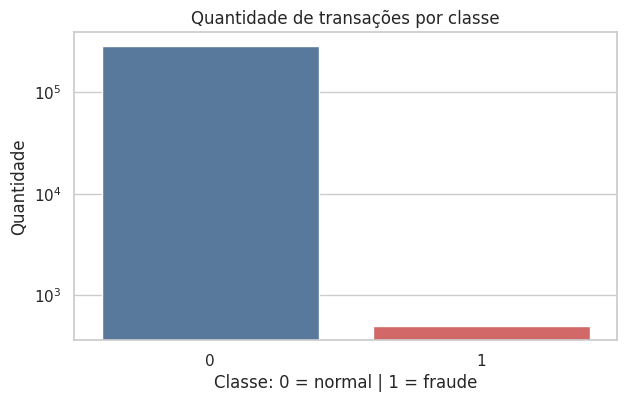

In [23]:
contagem_classes = df[NOME_COLUNA_ALVO].value_counts().sort_index()
proporcao_classes = (
    df[NOME_COLUNA_ALVO].value_counts(normalize=True).sort_index() * 100
)

resumo_classes = pd.DataFrame({
    "quantidade": contagem_classes,
    "porcentagem": proporcao_classes
})
display(resumo_classes)

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=NOME_COLUNA_ALVO, palette=["#4C78A8", "#E45756"])
plt.title("Quantidade de transações por classe")
plt.xlabel("Classe: 0 = normal | 1 = fraude")
plt.ylabel("Quantidade")
plt.yscale("log")
plt.show()

## 6. Criar uma variável mais adequada para o valor

Valores financeiros podem variar muito. `np.log1p` comprime valores grandes e também funciona quando o valor é zero. A coluna original `Amount` será removida para não duplicar a mesma informação.

In [24]:
def criar_variaveis(dados):
    dados_transformados = dados.copy()
    dados_transformados["Amount_log"] = np.log1p(dados_transformados["Amount"])
    dados_transformados = dados_transformados.drop(columns=["Amount"])
    return dados_transformados

df_modelo = criar_variaveis(df)
display(df_modelo[["Time", "Amount_log", "Class"]].head())

,Time,Amount_log,Class
0,0.0,5.014760,0
1,0.0,1.305626,0
2,1.0,5.939276,0
3,1.0,4.824306,0
4,2.0,4.262539,0


## 7. Separar treino, validação e teste

- **Treino:** ensina o modelo.
- **Validação:** ajuda a escolher configurações e o limiar.
- **Teste:** mede o resultado final apenas depois das escolhas.

`stratify` mantém a proporção rara de fraudes em cada parte. O teste não será usado para treinar, padronizar, aplicar SMOTE ou escolher o limiar.

In [25]:
X = df_modelo.drop(columns=[NOME_COLUNA_ALVO])
y = df_modelo[NOME_COLUNA_ALVO]

X_treino, X_temporario, y_treino, y_temporario = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEMENTE,
)

X_validacao, X_teste, y_validacao, y_teste = train_test_split(
    X_temporario,
    y_temporario,
    test_size=0.50,
    stratify=y_temporario,
    random_state=SEMENTE,
)

print("Treino:", X_treino.shape, "| fraudes:", int(y_treino.sum()))
print("Validação:", X_validacao.shape, "| fraudes:", int(y_validacao.sum()))
print("Teste:", X_teste.shape, "| fraudes:", int(y_teste.sum()))

Treino: (199364, 30) | fraudes: 344
Validação: (42721, 30) | fraudes: 74
Teste: (42722, 30) | fraudes: 74


## 8. Função de avaliação

Esta função evita repetir código e garante que todos os modelos sejam avaliados da mesma maneira. Na matriz de confusão, o campo inferior esquerdo é especialmente importante: ele mostra fraudes que o modelo deixou passar.

In [26]:
resultados = []

def avaliar_modelo(nome, y_real, y_previsto, probabilidades):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_real,
        y_previsto,
        labels=[1],
        average=None,
        zero_division=0,
    )
    average_precision = average_precision_score(y_real, probabilidades)

    resultado = {
        "modelo": nome,
        "precision_fraude": float(precision[0]),
        "recall_fraude": float(recall[0]),
        "f1_fraude": float(f1[0]),
        "average_precision": float(average_precision),
    }
    resultados.append(resultado)

    print(f"\n===== {nome} =====")
    print(classification_report(
        y_real,
        y_previsto,
        target_names=["Normal", "Fraude"],
        digits=4,
        zero_division=0,
    ))

    matriz = confusion_matrix(y_real, y_previsto)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Fraude"],
        yticklabels=["Normal", "Fraude"],
    )
    plt.title(f"Matriz de confusão — {nome}")
    plt.xlabel("Classe prevista")
    plt.ylabel("Classe real")
    plt.show()
    return resultado

## 9. Modelo 1 — Regressão Logística

Este é o modelo inicial. O `Pipeline` aprende a padronização somente com o treino e depois aplica exatamente a mesma transformação aos dados novos. `class_weight='balanced'` aumenta a importância das fraudes durante o treinamento.


===== Regressão Logística — limiar 0.50 =====
              precision    recall  f1-score   support

      Normal     0.9998    0.9781    0.9888     42648
      Fraude     0.0649    0.8784    0.1209        74

    accuracy                         0.9779     42722
   macro avg     0.5324    0.9282    0.5549     42722
weighted avg     0.9982    0.9779    0.9873     42722



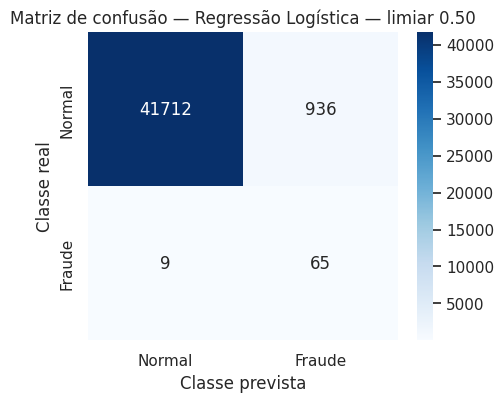

{'modelo': 'Regressão Logística — limiar 0.50',
 'precision_fraude': 0.06493506493506493,
 'recall_fraude': 0.8783783783783784,
 'f1_fraude': 0.12093023255813953,
 'average_precision': 0.791711335574966}

In [27]:
modelo_logistico = Pipeline([
    ("padronizacao", StandardScaler()),
    ("modelo", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=SEMENTE,
    )),
])

modelo_logistico.fit(X_treino, y_treino)
prob_logistica_teste = modelo_logistico.predict_proba(X_teste)[:, 1]
pred_logistica = (prob_logistica_teste >= 0.50).astype(int)

avaliar_modelo(
    "Regressão Logística — limiar 0.50",
    y_teste,
    pred_logistica,
    prob_logistica_teste,
)

## 10. Escolher o limiar na validação

O limiar padrão é `0.50`. O vídeo demonstra `0.30` para encontrar mais fraudes. Aqui o código escolhe automaticamente, **na validação**, o limiar com melhor F2-score. O F2 dá mais peso ao recall, mas ainda impede que a precision seja completamente ignorada.

Limiar escolhido na validação: 1.0000
Precision na validação: 0.7887
Recall na validação: 0.7568
F2 na validação: 0.7629

===== Regressão Logística — limiar 1.000 =====
              precision    recall  f1-score   support

      Normal     0.9996    0.9999    0.9998     42648
      Fraude     0.9077    0.7973    0.8489        74

    accuracy                         0.9995     42722
   macro avg     0.9537    0.8986    0.9243     42722
weighted avg     0.9995    0.9995    0.9995     42722



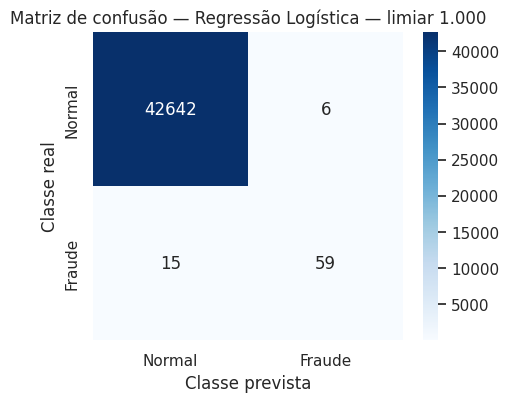

{'modelo': 'Regressão Logística — limiar 1.000',
 'precision_fraude': 0.9076923076923077,
 'recall_fraude': 0.7972972972972973,
 'f1_fraude': 0.8489208633093526,
 'average_precision': 0.791711335574966}

In [28]:
prob_logistica_validacao = modelo_logistico.predict_proba(X_validacao)[:, 1]
precision_val, recall_val, limiares = precision_recall_curve(
    y_validacao,
    prob_logistica_validacao,
)

precision_para_limiares = precision_val[:-1]
recall_para_limiares = recall_val[:-1]
f2 = (
    5 * precision_para_limiares * recall_para_limiares
    / (4 * precision_para_limiares + recall_para_limiares + 1e-12)
)
melhor_indice = int(np.argmax(f2))
melhor_limiar = float(limiares[melhor_indice])

print(f"Limiar escolhido na validação: {melhor_limiar:.4f}")
print(f"Precision na validação: {precision_para_limiares[melhor_indice]:.4f}")
print(f"Recall na validação: {recall_para_limiares[melhor_indice]:.4f}")
print(f"F2 na validação: {f2[melhor_indice]:.4f}")

pred_logistica_ajustada = (prob_logistica_teste >= melhor_limiar).astype(int)
avaliar_modelo(
    f"Regressão Logística — limiar {melhor_limiar:.3f}",
    y_teste,
    pred_logistica_ajustada,
    prob_logistica_teste,
)

## 11. Modelo 2 — Random Forest

O Random Forest combina várias árvores de decisão. O limite de profundidade reduz o risco de o modelo simplesmente decorar os dados de treino.


===== Random Forest =====
              precision    recall  f1-score   support

      Normal     0.9996    0.9998    0.9997     42648
      Fraude     0.8788    0.7838    0.8286        74

    accuracy                         0.9994     42722
   macro avg     0.9392    0.8918    0.9141     42722
weighted avg     0.9994    0.9994    0.9994     42722



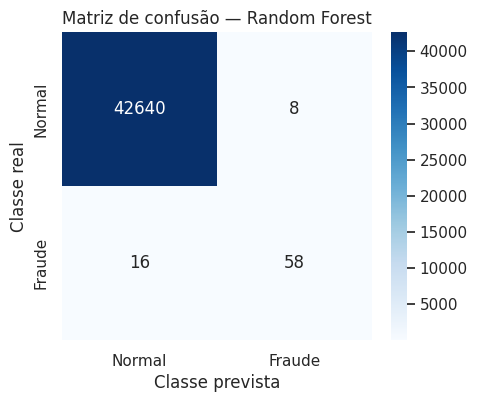

{'modelo': 'Random Forest',
 'precision_fraude': 0.8787878787878788,
 'recall_fraude': 0.7837837837837838,
 'f1_fraude': 0.8285714285714286,
 'average_precision': 0.7901347281254937}

In [11]:
modelo_random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight="balanced",
    n_jobs=-1,
    random_state=SEMENTE,
)

modelo_random_forest.fit(X_treino, y_treino)
prob_rf_teste = modelo_random_forest.predict_proba(X_teste)[:, 1]
pred_rf = (prob_rf_teste >= 0.50).astype(int)

avaliar_modelo(
    "Random Forest",
    y_teste,
    pred_rf,
    prob_rf_teste,
)

## 12. Modelo 3 — Regressão Logística com SMOTE

SMOTE cria exemplos sintéticos da classe rara. Ele está dentro de um pipeline para ser aplicado **somente ao treinamento**. Aplicar SMOTE antes de separar os dados causaria vazamento e deixaria a avaliação artificialmente otimista.


===== Regressão Logística com SMOTE =====
              precision    recall  f1-score   support

      Normal     0.9998    0.9770    0.9882     42648
      Fraude     0.0621    0.8784    0.1160        74

    accuracy                         0.9768     42722
   macro avg     0.5309    0.9277    0.5521     42722
weighted avg     0.9982    0.9768    0.9867     42722



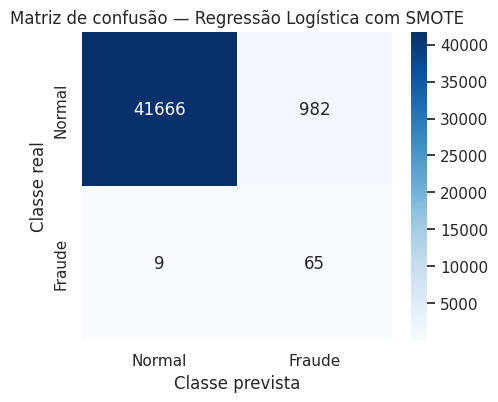

{'modelo': 'Regressão Logística com SMOTE',
 'precision_fraude': 0.06208213944603629,
 'recall_fraude': 0.8783783783783784,
 'f1_fraude': 0.1159678858162355,
 'average_precision': 0.7944941850739754}

In [12]:
modelo_smote = ImbPipeline([
    ("padronizacao", StandardScaler()),
    ("smote", SMOTE(random_state=SEMENTE)),
    ("modelo", LogisticRegression(max_iter=1000, random_state=SEMENTE)),
])

modelo_smote.fit(X_treino, y_treino)
prob_smote_teste = modelo_smote.predict_proba(X_teste)[:, 1]
pred_smote = (prob_smote_teste >= 0.50).astype(int)

avaliar_modelo(
    "Regressão Logística com SMOTE",
    y_teste,
    pred_smote,
    prob_smote_teste,
)

## 13. Modelo 4 — XGBoost

O XGBoost treina árvores em sequência: cada nova árvore tenta corrigir erros das anteriores. `scale_pos_weight` dá à fraude um peso proporcional ao desbalanceamento observado somente no treino.

Peso calculado para a classe de fraude: 578.55

===== XGBoost =====
              precision    recall  f1-score   support

      Normal     0.9997    0.9956    0.9977     42648
      Fraude     0.2500    0.8514    0.3865        74

    accuracy                         0.9953     42722
   macro avg     0.6249    0.9235    0.6921     42722
weighted avg     0.9984    0.9953    0.9966     42722



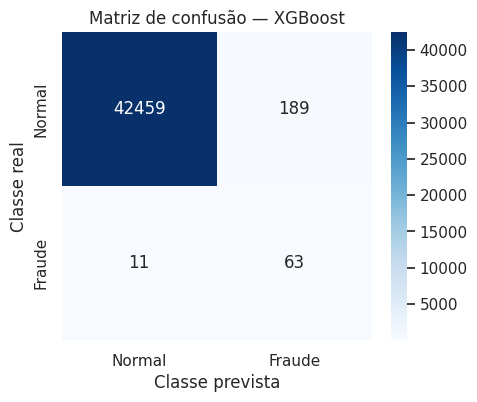

{'modelo': 'XGBoost',
 'precision_fraude': 0.25,
 'recall_fraude': 0.8513513513513513,
 'f1_fraude': 0.38650306748466257,
 'average_precision': 0.7566369910656541}

In [13]:
quantidade_normais = int((y_treino == 0).sum())
quantidade_fraudes = int((y_treino == 1).sum())
peso_fraude = quantidade_normais / quantidade_fraudes
print(f"Peso calculado para a classe de fraude: {peso_fraude:.2f}")

modelo_xgboost = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.10,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=peso_fraude,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEMENTE,
)

modelo_xgboost.fit(X_treino, y_treino)
prob_xgb_teste = modelo_xgboost.predict_proba(X_teste)[:, 1]
pred_xgb = (prob_xgb_teste >= 0.50).astype(int)

avaliar_modelo(
    "XGBoost",
    y_teste,
    pred_xgb,
    prob_xgb_teste,
)

## 14. Comparar os modelos

A tabela coloca todas as métricas da fraude lado a lado. Para este problema, observe primeiro o recall, depois a precision e o F1. Average Precision resume a qualidade do ranqueamento das probabilidades.

In [14]:
tabela_resultados = (
    pd.DataFrame(resultados)
    .drop_duplicates(subset=["modelo"], keep="last")
    .sort_values(["recall_fraude", "precision_fraude"], ascending=False)
    .reset_index(drop=True)
)
display(tabela_resultados.style.format({
    "precision_fraude": "{:.4f}",
    "recall_fraude": "{:.4f}",
    "f1_fraude": "{:.4f}",
    "average_precision": "{:.4f}",
}))

,modelo,precision_fraude,recall_fraude,f1_fraude,average_precision
0,Regressão Logística — limiar 0.50,0.0649,0.8784,0.1209,0.7917
1,Regressão Logística com SMOTE,0.0621,0.8784,0.1160,0.7945
2,XGBoost,0.2500,0.8514,0.3865,0.7566
3,Regressão Logística — limiar 1.000,0.9077,0.7973,0.8489,0.7917
4,Random Forest,0.8788,0.7838,0.8286,0.7901


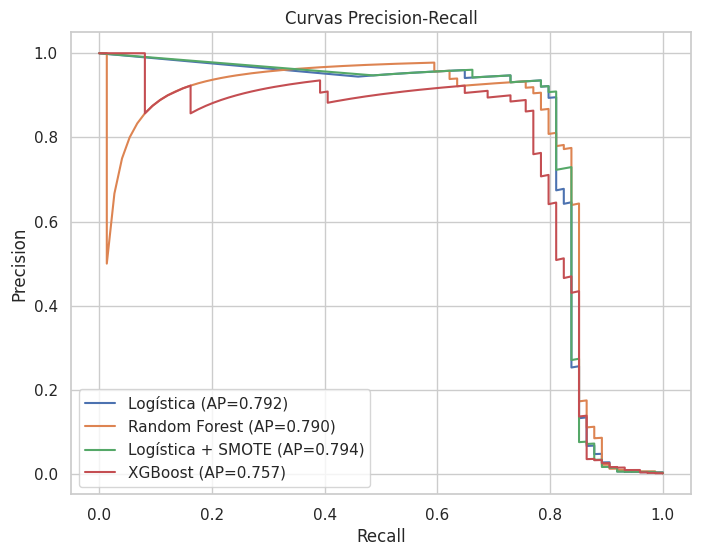

In [15]:
curvas = {
    "Logística": prob_logistica_teste,
    "Random Forest": prob_rf_teste,
    "Logística + SMOTE": prob_smote_teste,
    "XGBoost": prob_xgb_teste,
}

plt.figure(figsize=(8, 6))
for nome, probabilidades in curvas.items():
    precision_curva, recall_curva, _ = precision_recall_curve(
        y_teste, probabilidades
    )
    ap = average_precision_score(y_teste, probabilidades)
    plt.plot(recall_curva, precision_curva, label=f"{nome} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall")
plt.legend()
plt.show()

## 15. Ajuste opcional de hiperparâmetros

Esta célula testa pequenas combinações de configurações do XGBoost. Ela pode demorar alguns minutos. O teste final continua protegido porque a busca usa somente o conjunto de treino. Execute-a para reproduzir a parte de GridSearchCV mostrada no vídeo.

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores parâmetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Melhor recall médio na validação cruzada: 0.8982

===== XGBoost ajustado =====
              precision    recall  f1-score   support

      Normal     0.9997    0.9896    0.9947     42648
      Fraude     0.1248    0.8514    0.2176        74

    accuracy                         0.9894     42722
   macro avg     0.5622    0.9205    0.6061     42722
weighted avg     0.9982    0.9894    0.9933     42722



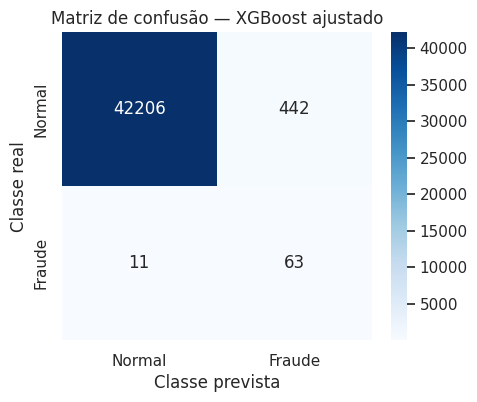

{'modelo': 'XGBoost ajustado',
 'precision_fraude': 0.12475247524752475,
 'recall_fraude': 0.8513513513513513,
 'f1_fraude': 0.21761658031088082,
 'average_precision': 0.7211575596860745}

In [16]:
parametros = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.10],
}

modelo_base_busca = XGBClassifier(
    scale_pos_weight=peso_fraude,
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=SEMENTE,
)

busca = GridSearchCV(
    estimator=modelo_base_busca,
    param_grid=parametros,
    scoring="recall",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
busca.fit(X_treino, y_treino)

print("Melhores parâmetros:", busca.best_params_)
print(f"Melhor recall médio na validação cruzada: {busca.best_score_:.4f}")

melhor_xgboost = busca.best_estimator_
prob_melhor_xgb = melhor_xgboost.predict_proba(X_teste)[:, 1]
pred_melhor_xgb = (prob_melhor_xgb >= 0.50).astype(int)
avaliar_modelo(
    "XGBoost ajustado",
    y_teste,
    pred_melhor_xgb,
    prob_melhor_xgb,
)

## 16. Importância das variáveis

Quanto maior a barra, mais a variável ajudou as decisões do modelo. Como `V1` a `V28` são componentes de PCA, elas podem ser importantes sem possuir uma interpretação comercial direta.

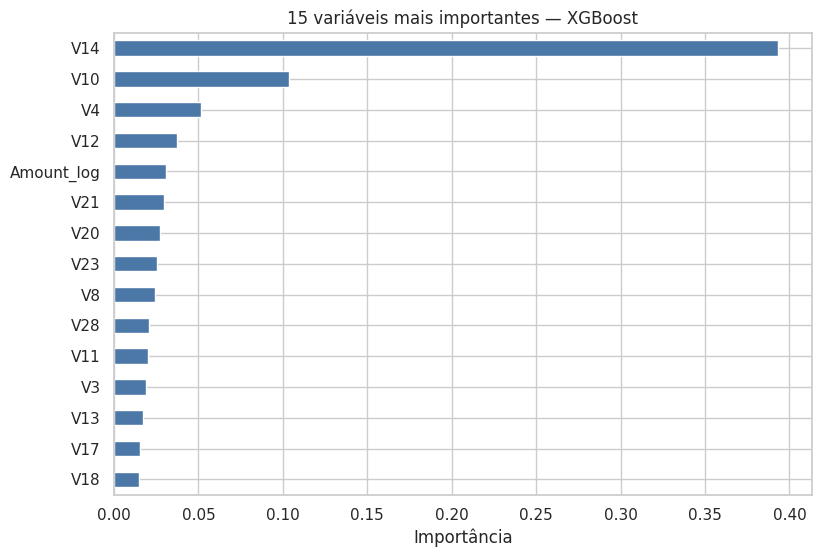

,importancia
V14,0.393434
V10,0.103415
V4,0.051510
V12,0.037141
Amount_log,0.030461
V21,0.029324
V20,0.027070
V23,0.025291
V8,0.024161
V28,0.020889


In [17]:
importancias = pd.Series(
    modelo_xgboost.feature_importances_,
    index=X_treino.columns,
).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
importancias.head(15).sort_values().plot(kind="barh", color="#4C78A8")
plt.title("15 variáveis mais importantes — XGBoost")
plt.xlabel("Importância")
plt.show()
display(importancias.head(15).to_frame("importancia"))

## 17. Explicabilidade com SHAP

SHAP mostra como cada variável empurra as previsões para fraude ou para normalidade. Para não deixar o Colab lento, utilizamos somente uma amostra do teste.

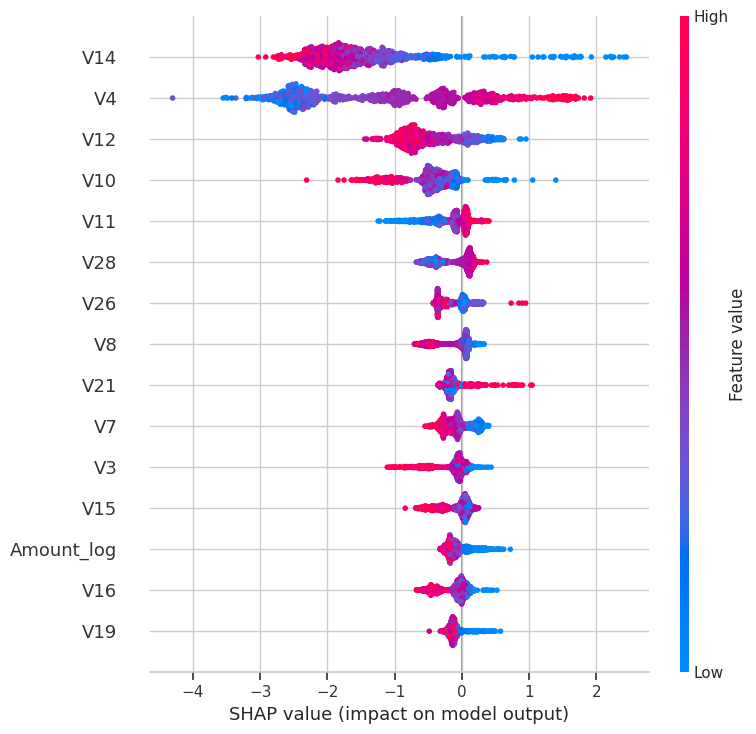

In [18]:
import shap

amostra_shap = X_teste.sample(
    n=min(1000, len(X_teste)),
    random_state=SEMENTE,
)

explicador = shap.TreeExplainer(modelo_xgboost)
valores_shap = explicador.shap_values(amostra_shap)
shap.summary_plot(valores_shap, amostra_shap, max_display=15)

## 18. Salvar o modelo e os resultados

Esta célula cria três arquivos no armazenamento temporário do Colab. Eles servem como prova dos resultados e permitem reutilizar o modelo sem treiná-lo novamente.

In [19]:
PASTA_SAIDA = Path("resultados_projeto")
PASTA_SAIDA.mkdir(exist_ok=True)

tabela_resultados = (
    pd.DataFrame(resultados)
    .drop_duplicates(subset=["modelo"], keep="last")
)
tabela_resultados.to_csv(PASTA_SAIDA / "comparacao_modelos.csv", index=False)
joblib.dump(modelo_xgboost, PASTA_SAIDA / "modelo_xgboost.joblib")

metadados = {
    "colunas": list(X_treino.columns),
    "classe_normal": 0,
    "classe_fraude": 1,
    "semente": SEMENTE,
    "limiar_logistica_escolhido_na_validacao": melhor_limiar,
}
with open(PASTA_SAIDA / "metadados.json", "w", encoding="utf-8") as arquivo:
    json.dump(metadados, arquivo, ensure_ascii=False, indent=2)

print("Arquivos criados:")
for caminho in PASTA_SAIDA.iterdir():
    print("-", caminho)

Arquivos criados:
- resultados_projeto/metadados.json
- resultados_projeto/comparacao_modelos.csv
- resultados_projeto/modelo_xgboost.joblib


## 19. Conclusão pessoal — preencha depois de executar

Substitua os trechos entre colchetes pelos números que apareceram na sua tabela:

> Neste projeto, foram comparados os modelos Regressão Logística, Regressão Logística com SMOTE, Random Forest e XGBoost para detectar fraudes em um conjunto de dados altamente desbalanceado. A Regressão Logística com limiar 0,50 e a Regressão Logística com SMOTE apresentaram o maior recall, de 87,84%, encontrando 65 das 74 fraudes do conjunto de teste. Entretanto, esses modelos produziram muitos falsos positivos e apresentaram precision de apenas 6,49% e 6,21%, respectivamente. O XGBoost obteve recall de 85,14% e precision de 25%. O melhor equilíbrio geral foi obtido pela Regressão Logística com limiar ajustado automaticamente, que apresentou precision de 90,77%, recall de 79,73% e o maior F1-score, de 84,89%. Esse modelo encontrou 59 das 74 fraudes e gerou somente 6 falsos positivos. Para uma aplicação que procura equilibrar fraudes detectadas e custo de falsos alarmes, eu escolheria a Regressão Logística com limiar ajustado. As análises de importância e SHAP indicaram que variáveis como V14, V4, V12, V10 e V11 tiveram grande influência nas previsões.

Checklist antes da entrega:

- [ ] Todas as células foram executadas na ordem.
- [ ] Não existe nenhuma mensagem de erro vermelha.
- [ ] A tabela de comparação apareceu.
- [ ] As matrizes de confusão e os gráficos apareceram.
- [ ] A conclusão foi preenchida com os seus próprios resultados.
- [ ] O notebook foi salvo com as saídas visíveis.
- [ ] O notebook, README e requirements.txt foram enviados ao GitHub.